# 01 — Dataset Understanding and Descriptive Analysis (Task 3)

Brief section 4: summary statistics, histograms/box plots (raw and log scale),
revenue by country, Pareto chart of revenue concentration, monthly/weekly revenue
trends, revenue by day of week and hour of day. Turn every observation into a
business insight (section 4.3).

In [1]:
import sys
sys.path.append('../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

clean = pd.read_csv('../../data/processed/invoice_lines_clean.csv', parse_dates=['InvoiceDate'])
customers = pd.read_csv('../../data/processed/customer_table.csv')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
# Sales-only view for revenue analyses (no cancellations, positive qty)
sales = clean[(~clean['IsCancellation']) & (clean['Quantity'] > 0)].copy()
sales['Month'] = sales['InvoiceDate'].dt.to_period('M').dt.to_timestamp()

import os
os.makedirs('../../reports/figures', exist_ok=True)   # save every chart for the report/slides

## Summary statistics
Quantity, Price, line revenue, and customer-level features.

In [3]:
sales[['Quantity','Price','LineRevenue']].describe(percentiles=[.5,.9,.99]).round(2)

,Quantity,Price,LineRevenue
count,1003340.00,1003340.00,1003340.00
mean,11.00,3.34,19.30
std,67.45,4.73,65.31
min,1.00,0.03,0.06
50%,4.00,2.10,10.08
90%,24.00,7.62,32.85
99%,108.00,16.95,179.00
max,19152.00,1157.15,15818.40


In [4]:
cols = ['Recency','Frequency','Monetary','DistinctProducts','TenureDays',
        'AvgBasketValue','CancellationRate']
customers[cols].describe(percentiles=[.5,.9,.99]).round(2)

,Recency,Frequency,Monetary,DistinctProducts,TenureDays,AvgBasketValue,CancellationRate
count,5253.00,5253.0,5253.00,5253.00,5253.00,5253.00,5253.00
mean,205.73,5.7,2579.59,74.48,429.92,362.69,0.11
std,173.96,11.2,12040.97,104.85,180.45,502.42,0.17
min,0.00,1.0,1.55,1.00,0.00,1.55,0.00
50%,162.00,3.0,776.46,41.00,472.00,275.04,0.00
90%,472.00,12.0,4872.56,178.00,639.00,631.29,0.38
99%,637.00,42.0,24400.08,462.40,646.00,1843.38,0.57
max,646.00,284.0,456780.49,2178.00,646.00,14844.77,0.80


## Distributions (raw vs log scale)

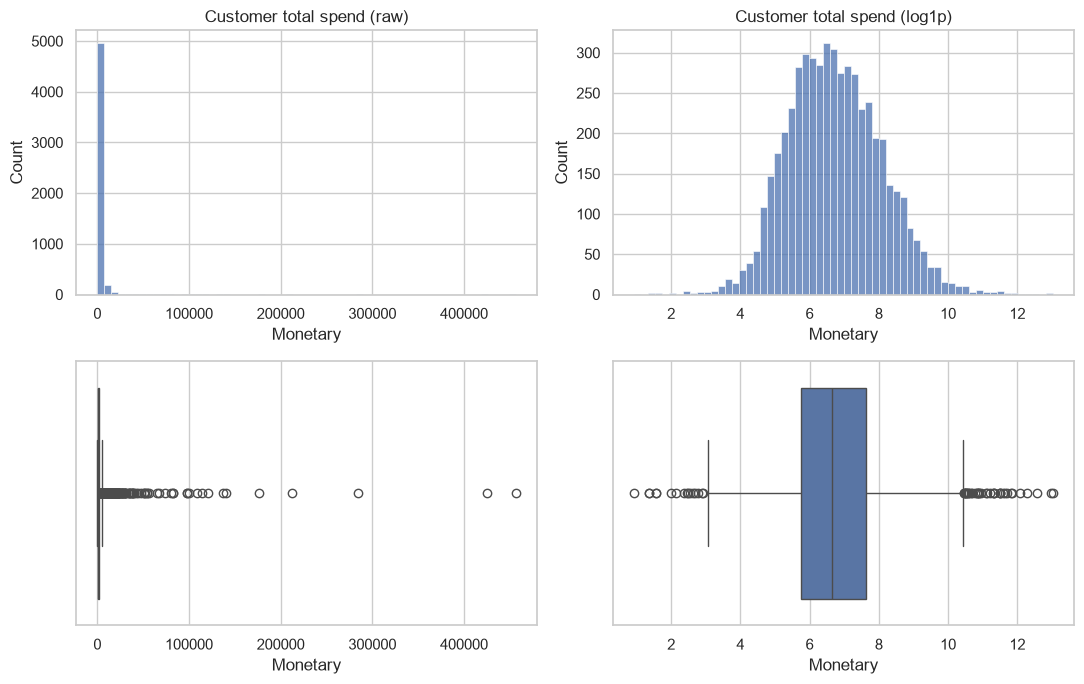

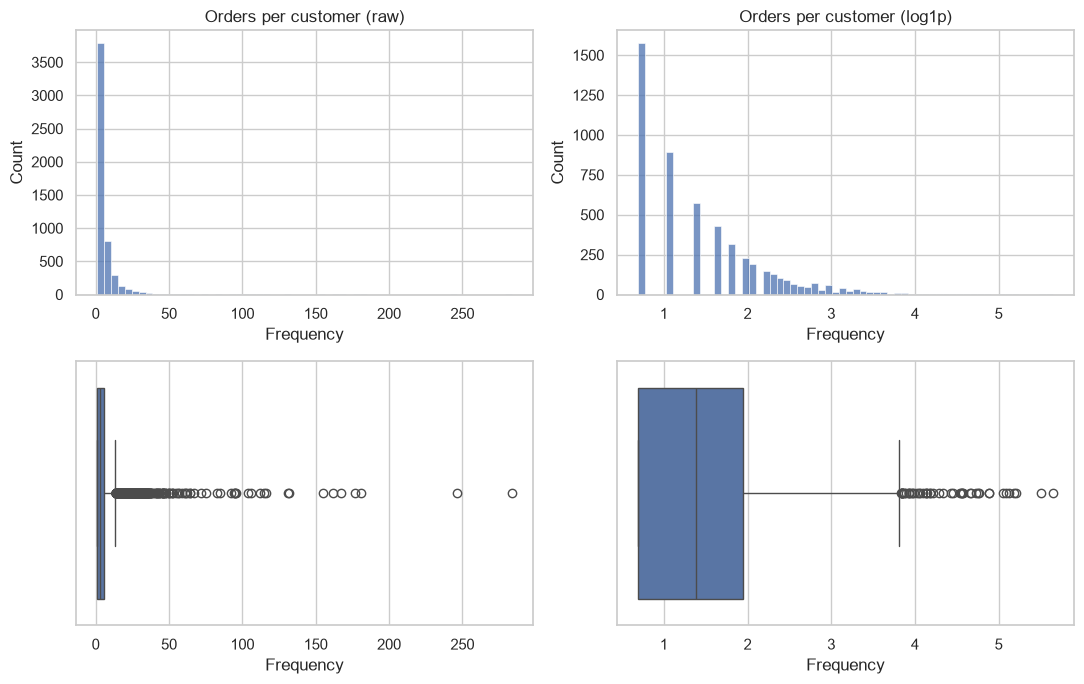

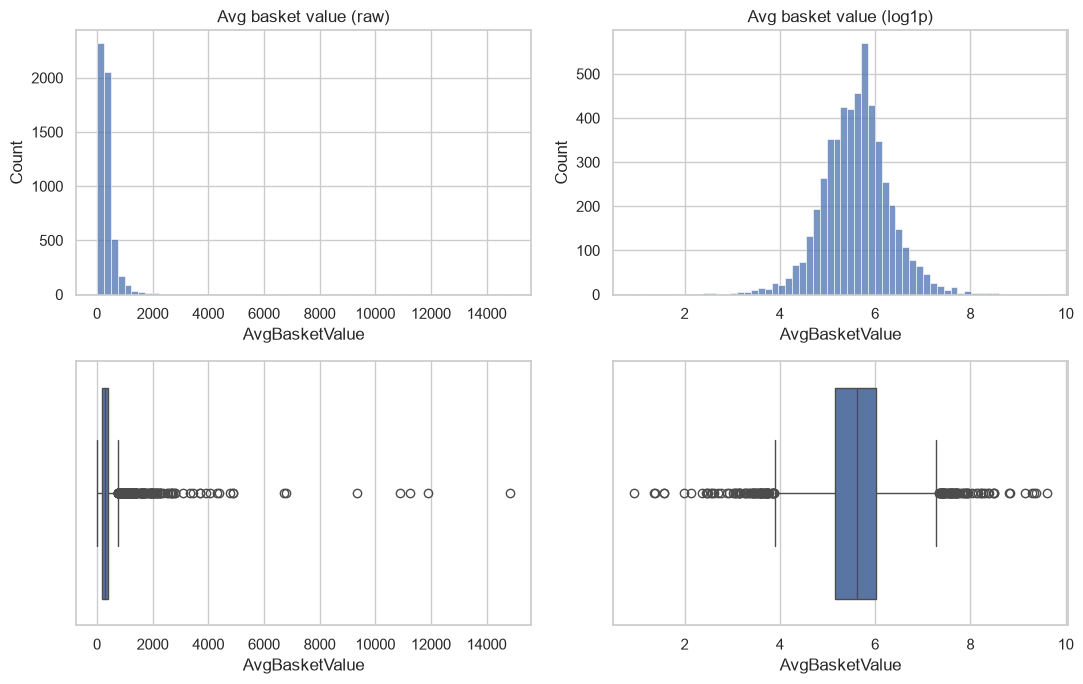

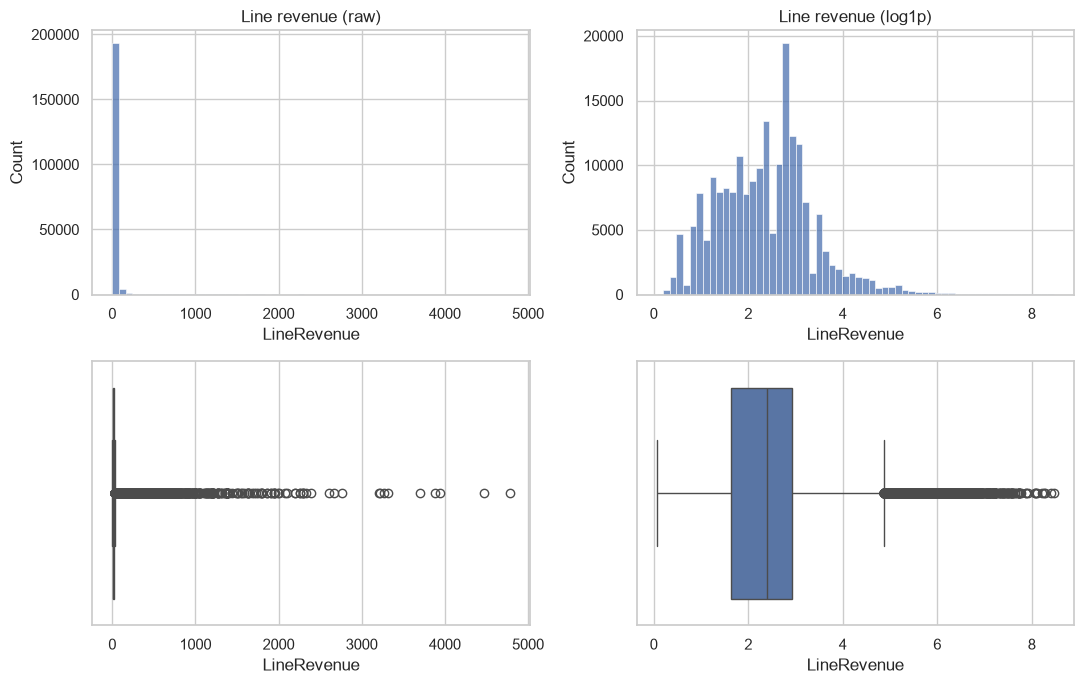

In [5]:

def raw_vs_log(df, col, title):
    fig, ax = plt.subplots(2, 2, figsize=(11, 7))
    sns.histplot(df[col], bins=60, ax=ax[0,0]);            ax[0,0].set_title(f'{title} (raw)')
    sns.histplot(np.log1p(df[col]), bins=60, ax=ax[0,1]);  ax[0,1].set_title(f'{title} (log1p)')
    sns.boxplot(x=df[col], ax=ax[1,0])
    sns.boxplot(x=np.log1p(df[col]), ax=ax[1,1])
    plt.tight_layout()
    plt.savefig(f'../../reports/figures/dist_{col}.png', dpi=150)
    plt.show()

raw_vs_log(customers, 'Monetary', 'Customer total spend')
raw_vs_log(customers, 'Frequency', 'Orders per customer')
raw_vs_log(customers, 'AvgBasketValue', 'Avg basket value')
raw_vs_log(sales.sample(200_000, random_state=1), 'LineRevenue', 'Line revenue')

In [6]:
customers.nlargest(10, 'Monetary')[['CustomerID','Monetary','Frequency','IsUK']]

,CustomerID,Monetary,Frequency,IsUK
5085,18102.0,456780.49,112,1
2022,14646.0,425343.12,115,0
1579,14156.0,284748.59,131,0
2256,14911.0,212195.41,284,0
1169,13694.0,176512.71,132,1
4559,17511.0,140446.24,50,1
4511,17450.0,136695.00,28,1
64,12415.0,121206.72,18,0
3827,16684.0,114372.71,45,1
2390,15061.0,108428.43,116,1


## Revenue by country

UK share of revenue: 85.3%


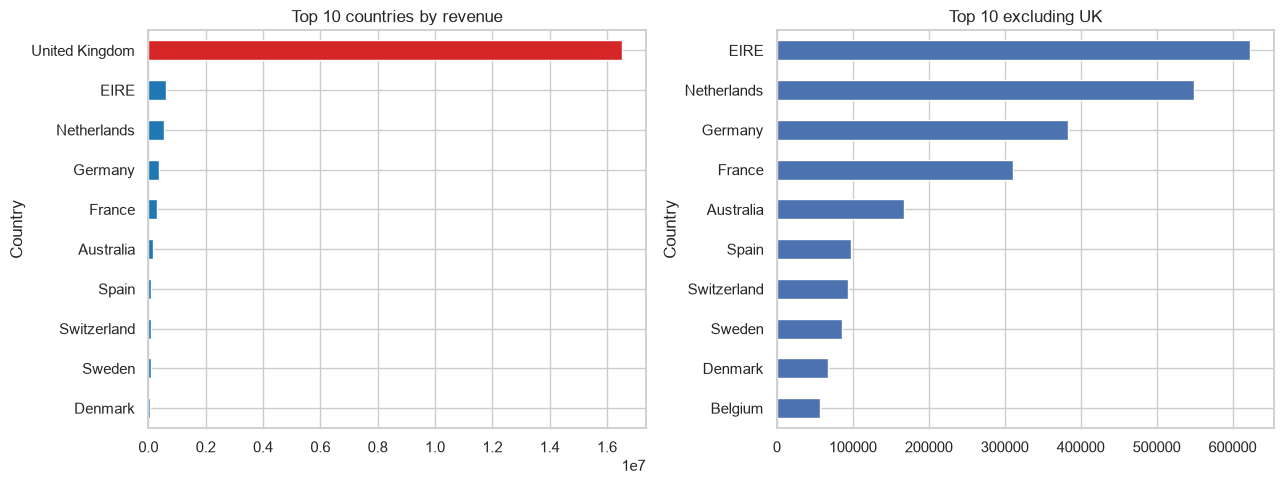

In [7]:

rev_country = sales.groupby('Country')['LineRevenue'].sum().sort_values(ascending=False)
share = (rev_country / rev_country.sum() * 100).round(2)
print('UK share of revenue: %.1f%%' % share['United Kingdom'])

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
rev_country.head(10).plot.barh(ax=ax[0], color=['tab:red'] + ['tab:blue']*9).invert_yaxis()
ax[0].set_title('Top 10 countries by revenue')
rev_country.drop('United Kingdom').head(10).plot.barh(ax=ax[1]).invert_yaxis()
ax[1].set_title('Top 10 excluding UK')
plt.tight_layout(); plt.savefig('../../reports/figures/revenue_country.png', dpi=150); plt.show()

## Pareto chart of cumulative revenue by customer

Top 1% of customers -> 30.8% of revenue
Top 5% of customers -> 50.6% of revenue
Top 10% of customers -> 62.7% of revenue
Top 20% of customers -> 76.4% of revenue
80% of revenue comes from the top 23.9% of customers


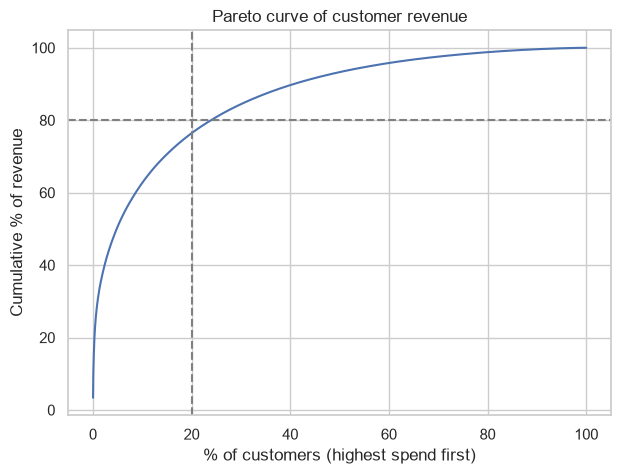

In [8]:

c = customers.sort_values('Monetary', ascending=False).reset_index(drop=True)
c['cum_rev_share']  = c['Monetary'].cumsum() / c['Monetary'].sum()
c['cum_cust_share'] = (c.index + 1) / len(c)

for p in [0.01, 0.05, 0.10, 0.20]:
    print(f'Top {p:.0%} of customers -> {c.loc[c.cum_cust_share >= p, "cum_rev_share"].iloc[0]:.1%} of revenue')

x80 = c.loc[c.cum_rev_share >= 0.8, 'cum_cust_share'].iloc[0]
print(f'80% of revenue comes from the top {x80:.1%} of customers')

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(c['cum_cust_share']*100, c['cum_rev_share']*100)
ax.axvline(20, ls='--', c='grey'); ax.axhline(80, ls='--', c='grey')
ax.set_xlabel('% of customers (highest spend first)')
ax.set_ylabel('Cumulative % of revenue')
ax.set_title('Pareto curve of customer revenue')
plt.savefig('../../reports/figures/pareto.png', dpi=150); plt.show()

## Monthly and weekly revenue trends

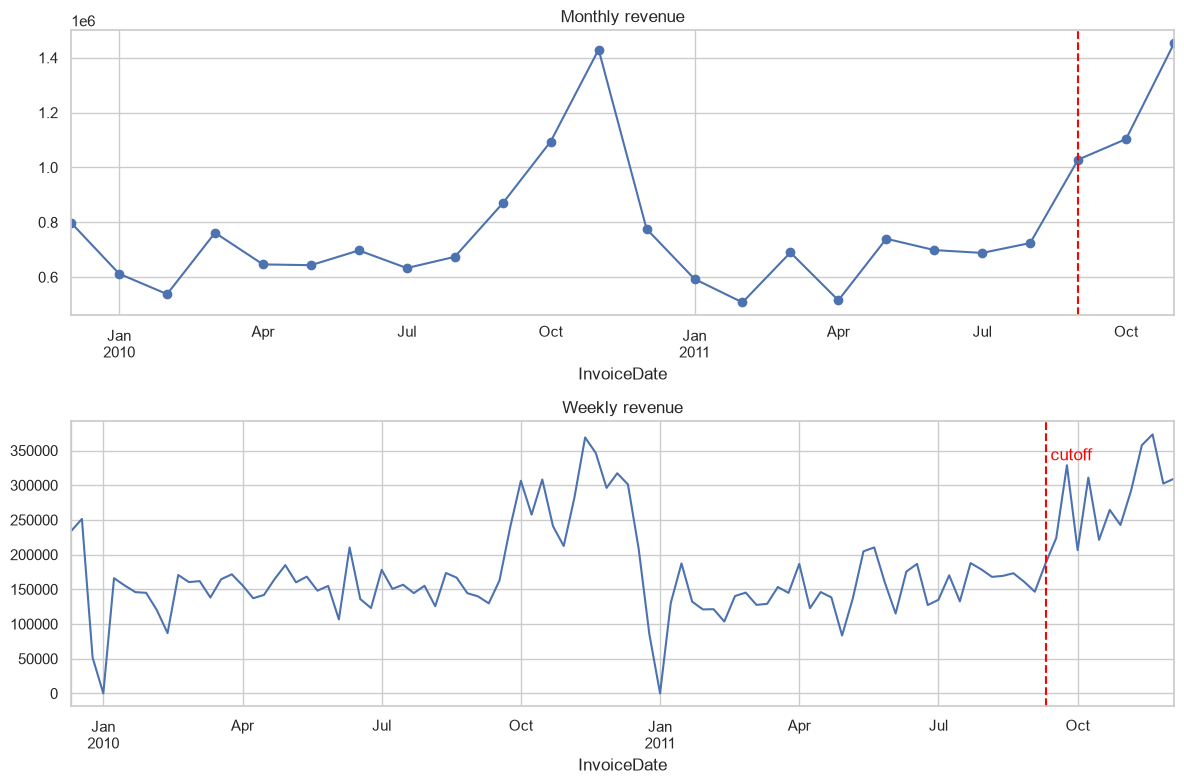

In [9]:

weekly  = sales.set_index('InvoiceDate')['LineRevenue'].resample('W').sum()
monthly = sales.set_index('InvoiceDate')['LineRevenue'].resample('MS').sum()

# drop partial first/last periods
weekly  = weekly.iloc[1:-1]
monthly = monthly.iloc[:-1]        # Dec 2011 is incomplete

fig, ax = plt.subplots(2, 1, figsize=(12, 8))
monthly.plot(ax=ax[0], marker='o'); ax[0].set_title('Monthly revenue')
weekly.plot(ax=ax[1]);              ax[1].set_title('Weekly revenue')
for a in ax:
    a.axvline(pd.Timestamp('2011-09-09'), ls='--', c='red')   # cutoff date
ax[1].text(pd.Timestamp('2011-09-09'), weekly.max()*0.9, ' cutoff', color='red')
plt.tight_layout(); plt.savefig('../../reports/figures/revenue_trend.png', dpi=150); plt.show()

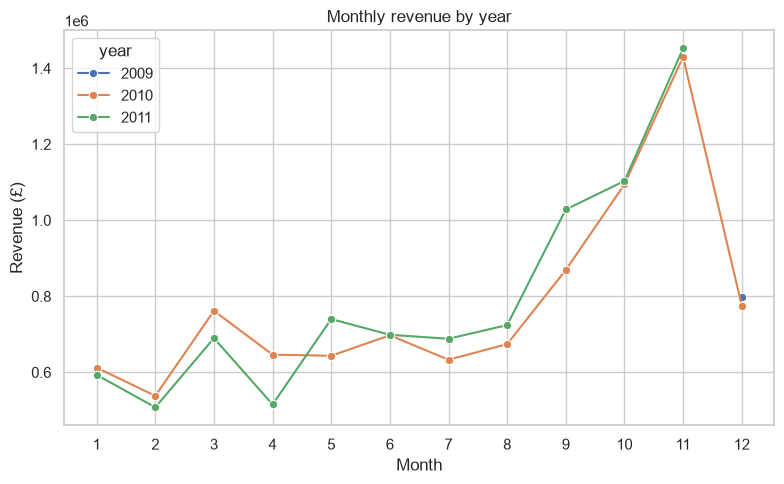

In [10]:
m = monthly.to_frame('rev')
m['year'] = m.index.year.astype(str)
m['month'] = m.index.month
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=m, x='month', y='rev', hue='year', marker='o', ax=ax)
ax.set_xticks(range(1, 13)); ax.set_title('Monthly revenue by year')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue (£)')
plt.tight_layout(); plt.savefig('../../reports/figures/revenue_yoy.png', dpi=150); plt.show()

## Revenue by day of week and hour of day

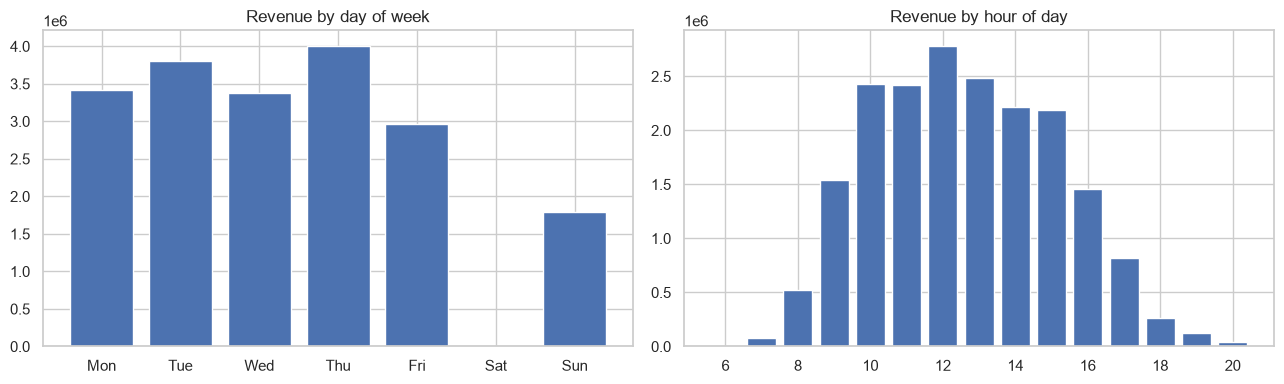

In [11]:

sales['dow']  = sales['InvoiceDate'].dt.dayofweek
sales['hour'] = sales['InvoiceDate'].dt.hour
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

by_dow  = sales.groupby('dow')['LineRevenue'].sum().reindex(range(7), fill_value=0)
by_hour = sales.groupby('hour')['LineRevenue'].sum()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(days, by_dow.values); ax[0].set_title('Revenue by day of week')
ax[1].bar(by_hour.index, by_hour.values); ax[1].set_title('Revenue by hour of day')
plt.tight_layout(); plt.savefig('../../reports/figures/dow_hour.png', dpi=150); plt.show()

In [12]:
print('Customers:', len(customers), '| sales lines:', len(sales))
print('Max line revenue: %.2f | max price: %.2f' % (sales.LineRevenue.max(), sales.Price.max()))
print(customers[['Monetary','Frequency','AvgBasketValue','CancellationRate']].skew().round(2).to_dict())
print('Mean/median Monetary: %.2fx' % (customers.Monetary.mean()/customers.Monetary.median()))
print('Top-10 customers share: %.1f%%' % (c.head(10)['Monetary'].sum()/c['Monetary'].sum()*100))
print('Non-UK in top 10:', (c.head(10)['IsUK']==0).sum())
print('Non-UK share of customers: %.1f%%' % ((1-customers.IsUK.mean())*100))
print('Single-order customers: %.1f%%' % ((customers.Frequency==1).mean()*100))
top4 = rev_country.drop('United Kingdom').head(4)
print(top4.round(0).to_dict(), '-> %.1f%% of total revenue' % (top4.sum()/rev_country.sum()*100))
off = monthly[~monthly.index.month.isin([9,10,11,12])].median()
nov = monthly[monthly.index.month==11]
print('Nov revenue:', nov.round(0).to_dict())
print('Typical off-peak month: %.0f | Nov ratio: %.2fx' % (off, nov.mean()/off))
print(dict(zip(days, (by_dow/by_dow.sum()*100).round(1))))
print('Revenue share 10:00-15:59: %.1f%%' % (by_hour.loc[10:15].sum()/by_hour.sum()*100))
print(weekly.nsmallest(4).round(0))

Customers: 5253 | sales lines: 1003340
Max line revenue: 15818.40 | max price: 1157.15
{'Monetary': 24.28, 'Frequency': 10.49, 'AvgBasketValue': 13.92, 'CancellationRate': 1.3}
Mean/median Monetary: 3.32x
Top-10 customers share: 16.1%
Non-UK in top 10: 4
Non-UK share of customers: 8.7%
Single-order customers: 30.0%
{'EIRE': 623414.0, 'Netherlands': 549773.0, 'Germany': 383289.0, 'France': 311090.0} -> 9.6% of total revenue
Nov revenue: {Timestamp('2010-11-01 00:00:00'): 1429701.0, Timestamp('2011-11-01 00:00:00'): 1452116.0}
Typical off-peak month: 660189 | Nov ratio: 2.18x
{'Mon': 17.6, 'Tue': 19.6, 'Wed': 17.4, 'Thu': 20.7, 'Fri': 15.3, 'Sat': 0.1, 'Sun': 9.2}
Revenue share 10:00-15:59: 75.0%
InvoiceDate
2010-01-03        0.0
2011-01-02        0.0
2009-12-27    51672.0
2011-05-01    83392.0
Name: LineRevenue, dtype: float64



## Business insights

| # | Finding (from the output) | Business insight | Feeds into |
|---|---|---|---|
| 1 | Customer spend is heavily right-skewed (skewness 24.3): mean £2,580 vs median £776 (3.3×); 99th percentile £24,400; maximum £456,780. After a log transform the distribution is roughly bell-shaped. | The "average customer" is misleading, since a few very large accounts pull the mean up. Management should track medians and segments rather than averages. | Task 4 (log-scale/Welch tests with non-parametric checks), Task 5 (log spend / Gamma GLM) |
| 2 | Order lines are also skewed: median £10.08 vs mean £19.30; 99th percentile £179; largest line £15,818 (9,360 units). | A handful of bulk lines drive the top of the distribution. Outliers must be investigated and documented, not silently kept or dropped. | Task 3 data-quality notes, Task 5 (influential observations) |
| 3 | Revenue is highly concentrated: top 1% of customers = 30.8% of revenue, top 5% = 50.6%, top 10% = 62.7%, top 20% = 76.4%; 80% of revenue comes from the top 23.9%. The top 10 customers alone account for 16.1%. | Income depends on a small group of buyers, so losing even a few would hurt materially. Retention effort should be weighted towards high-value customers. | Task 5 (expected-profit targeting), Task 12 (risk: reduce dependence on top customers) |
| 4 | The UK generates 85.3% of revenue. The next markets are EIRE (£623k), Netherlands (£550k), Germany (£383k) and France (£311k), together 9.6% of revenue; the rest are very small. Yet 4 of the top-10 customers are non-UK, although only 8.7% of customers are international. | The business is UK-dependent, but a few international wholesalers are very valuable, which suggests international customers may place larger orders. This is a hypothesis to test formally. Most countries have very few customers, so country-level estimates will be unstable. | Task 4 (UK vs international tests), Task 8 (hierarchical Bayesian partial pooling) |
| 5 | Only 43.4% of customers repurchased in the 90 days after the cutoff; 30.0% of customers have placed only a single order and median recency is 162 days. | More than half of the customer base is inactive at any time, and nearly a third never return after a first purchase. This gap is the retention opportunity the project targets. | Task 5 (repurchase model), Task 10 (early-warning system) |
| 6 | Cancellation rate averages 11.4% per customer but the median is 0; the 90th percentile is 38% and the maximum 80%. | Cancellations are concentrated in a minority of customers rather than spread evenly. High-cancellation customers cost the business more (handling, returned stock) and are a candidate risk signal. | Task 5 (cancellation rate as a predictor), Task 12 (operational recommendations) |
| 7 | Strong seasonality: November revenue was £1.43M in 2010 and £1.45M in 2011, about 2.2× the typical off-peak month (median £660k). The rise starts in August/September and falls sharply in December. Outside Q4 the two years look similar. | Demand is driven by pre-Christmas gift buying. Inventory, staffing and cash flow must be built up from August/September. Because the pattern repeats each year it is predictable and plannable. | Task 9 (seasonality, forecasting), Task 12 (Q4 inventory planning) |
| 8 | The 90-day outcome window (9 Sep to early Dec 2011) sits inside the Q4 peak. | The 43.4% repurchase rate is measured during the busiest season and probably overstates the off-peak rate. Model results and campaign ROI should be interpreted with this in mind, and any experiment must account for timing. | Task 5 (limitations), Task 6 (seasonality confound) |
| 9 | Weekly revenue is £0 in the weeks ending 3 Jan 2010 and 2 Jan 2011, and low in the week ending 27 Dec 2009 (≈ £52k). | The business effectively pauses over the Christmas/New Year period. Retention campaigns should be timed before the shutdown, and these zero weeks must be handled as a structural break in time-series models. | Task 9 (decomposition/ARIMA), Task 10 (campaign scheduling) |
| 10 | Saturday accounts for only 0.1% of revenue (effectively no Saturday trading); Sunday is 9.2%, about half of a weekday; Thursday (20.7%) and Tuesday (19.6%) are the strongest days, Friday (15.3%) the weakest weekday. | Ordering follows a weekday business rhythm typical of trade customers, and Saturday is likely a non-operating day. Dispatch and customer-service staffing should follow this pattern, and emails should be sent early in the week. | Task 4 (ANOVA on day of week), Task 9 |
| 11 | 75.0% of revenue arrives between 10:00 and 15:59, peaking at 12:00; very little before 08:00 or after 18:00. | Customers order during business hours, consistent with small shops buying for their business. Campaigns should land in the morning before the midday peak, and customer-service capacity should cover 10:00 to 16:00. | Task 10 (dashboard/campaign timing) |
| 12 | Data quality: 277 non-product rows (samples, adjustments, vouchers, test items) and 3 large orders entered by mistake and reversed within minutes (81k units, 74k units, £38,970) were removed; about 22% of rows have no CustomerID. | Manual entries and reversals can distort revenue totals and customer features. Keeping missing-ID rows for sales totals but excluding them from customer models avoids losing revenue information while keeping customer-level analysis reliable. | Task 3 data-quality table, Task 5 (data pipeline) |

**Data notes:** Revenue is gross sales before returns (cancellations are excluded from revenue and captured through the cancellation rate). Rows with missing CustomerID are kept for sales totals (country, trends, day/hour) but excluded from customer-level analysis. The Pareto analysis uses pre-cutoff customer spend, so its totals differ from the full-period country revenue.
_Write 1 insight per finding, e.g. "the top X% of customers generate Y% of revenue..."_